# GSE282026 (Dataset 04) — load & QC kidney CosMx SpatialData

GEO human kidney CosMx WTX data ([GSE282026](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE282026)), sample `KidneyRun2Slide1`.

Loads `sdata.zarr`, checks that `.X` holds raw integer counts, and plots centroids, cell segmentation, and transcripts in a cropped ROI.

**Kernel:** `spatialdata`

In [ ]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import spatialdata as sd
import spatialdata_plot  # registers .pl accessor

RAW_DIR = Path("/mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_04/raw_data")
sys.path.insert(0, str(RAW_DIR.parent.parent.parent / "src"))

from load_explore import setup_notebook_paths
from spatial_plot import plot_gene_seg_transcripts

setup_notebook_paths(raw_dir=RAW_DIR)

SDATA_PATH = RAW_DIR / "sdata.zarr"

assert SDATA_PATH.is_dir(), f"Missing zarr store: {SDATA_PATH}"
print(f"Zarr path: {SDATA_PATH}")

/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Zarr path: /mnt/scratch2/Maycon/Hackathon/SJ_BioHack_2026/KIDS26-Team18/data/Dataset_04/raw_data/sdata.zarr


In [2]:
sdata = sd.read_zarr(SDATA_PATH)
adata = sdata["table"]

print("Tables:", list(sdata.tables.keys()))
print("Shapes:", list(sdata.shapes.keys()))
print("Points:", list(sdata.points.keys()))
print("Images:", list(sdata.images.keys()) or "(none)")
print(f"\nAnnData: {adata.n_obs:,} cells x {adata.n_vars:,} genes")
print(f"obs columns ({len(adata.obs.columns)}): {list(adata.obs.columns)[:12]} ...")
print(f"obsm keys: {list(adata.obsm.keys())}")
print(f"layers: {list(adata.layers.keys()) or '(none)'}")
print(f"Table region: {adata.uns['spatialdata_attrs']['region']}")

Tables: ['table']
Shapes: ['cell_boundaries']
Points: ['transcripts']
Images: (none)

AnnData: 260,979 cells x 6,519 genes
obs columns (81): ['RNA_nbclust_e8a1ce76.7e4f.4aa2.9ff8.a9e8a8e14460_1_clusters', 'RNA_nbclust_e8a1ce76.7e4f.4aa2.9ff8.a9e8a8e14460_1_posterior_probability', 'RNA_nbclust_0dccc116.0cc4.45ad.8d93.f913cb7fb09e_1_clusters', 'RNA_nbclust_0dccc116.0cc4.45ad.8d93.f913cb7fb09e_1_posterior_probability', 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK'] ...
obsm keys: ['spatial', 'global']
layers: (none)
Table region: cell_boundaries


In [3]:
# Sanity check: .X should hold integer raw RNA counts
x = adata.X
vals = x.data if hasattr(x, "data") else np.asarray(x).ravel()

assert vals.min() >= 0, f"Expected nonnegative counts, got min={vals.min()}"
assert np.allclose(vals, np.round(vals)), "Non-integer values in .X"

# exprMat includes Negative/SystemControl probes; compare RNA genes only to nCount_RNA
rna_mask = ~adata.var_names.str.match(r"^(Negative|SystemControl)")
row_sums = np.asarray(adata[:, rna_mask].X.sum(axis=1)).ravel()
ref = adata.obs["nCount_RNA"].to_numpy(dtype=float)
assert np.allclose(row_sums, ref, atol=5), "X row sums (RNA genes) must match obs['nCount_RNA']"

print(f"X holds integer counts (min={vals.min():.0f}, max={vals.max():.0f})")
print(f"Row-sum check vs nCount_RNA (RNA genes, atol=5): OK ({adata.n_obs:,} cells)")

X holds integer counts (min=1, max=1181)
Row-sum check vs nCount_RNA (RNA genes, atol=5): OK (260,979 cells)


In [4]:
# Crop ROI around tissue center (global pixel coordinates)
coords = adata.obsm["global"]
cx, cy = np.median(coords, axis=0)
half = 2500  # px window half-width
xmin, xmax = cx - half, cx + half
ymin, ymax = cy - half, cy + half

sdata_crop = sdata.query.bounding_box(
    axes=("x", "y"),
    min_coordinate=[xmin, ymin],
    max_coordinate=[xmax, ymax],
    target_coordinate_system="global",
    filter_table=False,
)

mask = (
    (coords[:, 0] >= xmin) & (coords[:, 0] <= xmax) &
    (coords[:, 1] >= ymin) & (coords[:, 1] <= ymax)
)
print(f"ROI: x=[{xmin:.0f}, {xmax:.0f}], y=[{ymin:.0f}, {ymax:.0f}]")
print(f"Cells in ROI: {mask.sum():,} / {adata.n_obs:,}")
print(f"Shapes in crop: {len(sdata_crop.shapes['cell_boundaries']):,}")
print(f"Transcripts in crop: {len(sdata_crop.points['transcripts']):,}")

GENE_CANDIDATES = ["LRP2", "PODXL", "AQP1", "WT1", "SLC12A3"]
GENE = next((g for g in GENE_CANDIDATES if g in adata.var_names), adata.var_names[0])
print(f"Demo gene: {GENE}")

/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/functools.py:912: UserWarning: The object has `points` element. Depending on the number of points, querying MAY suffer from performance issues. Please consider filtering the object before calling this function by calling the `subset()` method of `SpatialData`.
  return dispatch(args[0].__class__)(*args, **kw)


ROI: x=[48100, 53100], y=[54147, 59147]
Cells in ROI: 115 / 260,979
Shapes in crop: 127
Transcripts in crop: 41,127
Demo gene: LRP2


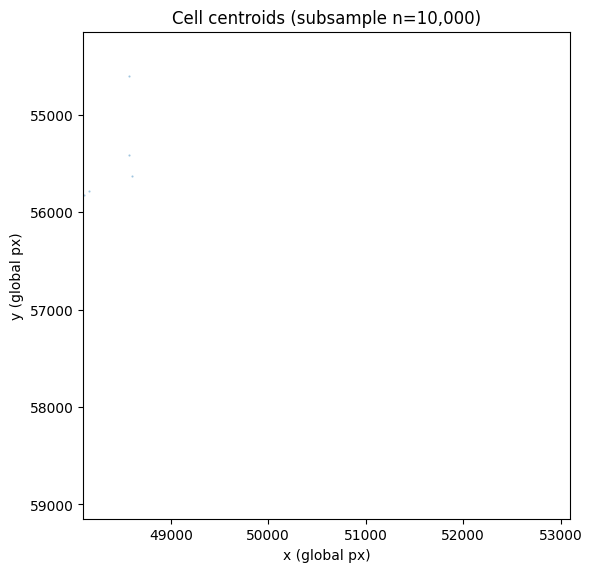

In [5]:
# Plot 1: cell centroids (subsample for speed)
rng = np.random.default_rng(0)
n_sub = min(10_000, adata.n_obs)
idx = rng.choice(adata.n_obs, size=n_sub, replace=False)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(coords[idx, 0], coords[idx, 1], s=0.3, alpha=0.4, rasterized=True)
ax.set_xlim(xmin, xmax)
ax.set_ylim(ymax, ymin)
ax.set_aspect("equal")
ax.set_xlabel("x (global px)")
ax.set_ylabel("y (global px)")
ax.set_title(f"Cell centroids (subsample n={n_sub:,})")
plt.tight_layout()
plt.show()

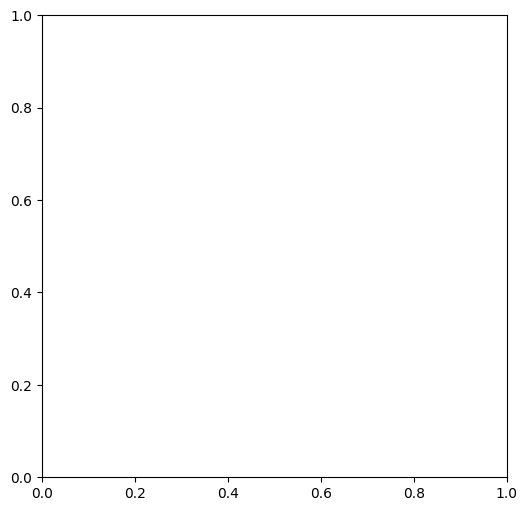

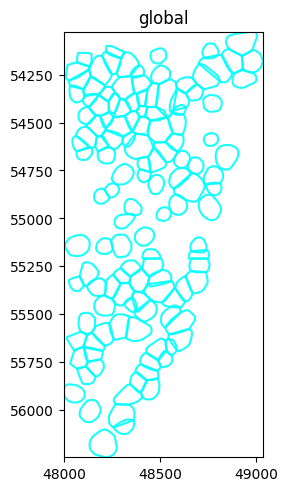

In [6]:
# Plot 2: cell segmentation (boundaries)
fig, ax = plt.subplots(figsize=(6, 6))
(
    sdata_crop.pl
    .render_shapes(
        "cell_boundaries",
        ax=ax,
        outline_color="cyan",
        outline_alpha=0.9,
        fill_alpha=0.0,
    )
    .pl.show(coordinate_systems="global")
)

/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/spatialdata_plot/pl/render.py:1019: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.scatter(


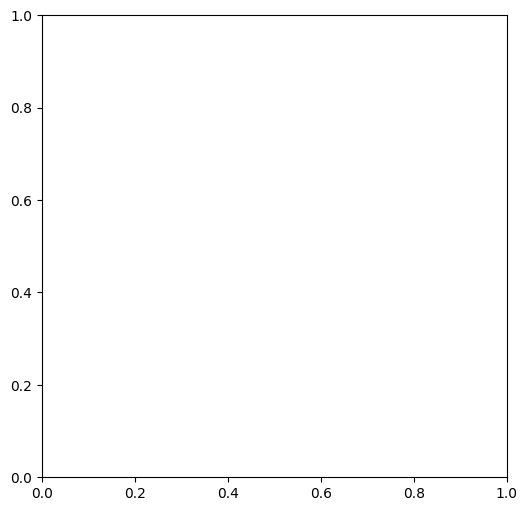

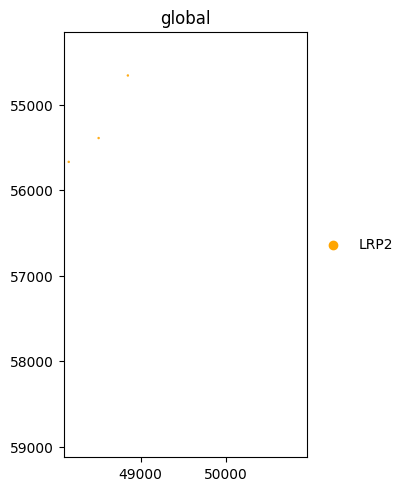

In [7]:
# Plot 3: transcripts for demo gene (spatialdata-plot: color column + groups)
fig, ax = plt.subplots(figsize=(6, 6))
(
    sdata_crop.pl
    .render_points(
        "transcripts",
        color="target",
        groups=GENE,
        palette="orange",
        ax=ax,
        alpha=0.6,
        size=0.5,
    )
    .pl.show(coordinate_systems="global")
)

/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/mnt/scratch1/miniconda3/envs/spatialdata/lib/python3.12/site-packages/spatialdata_plot/pl/render.py:1019: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  _cax = ax.scatter(


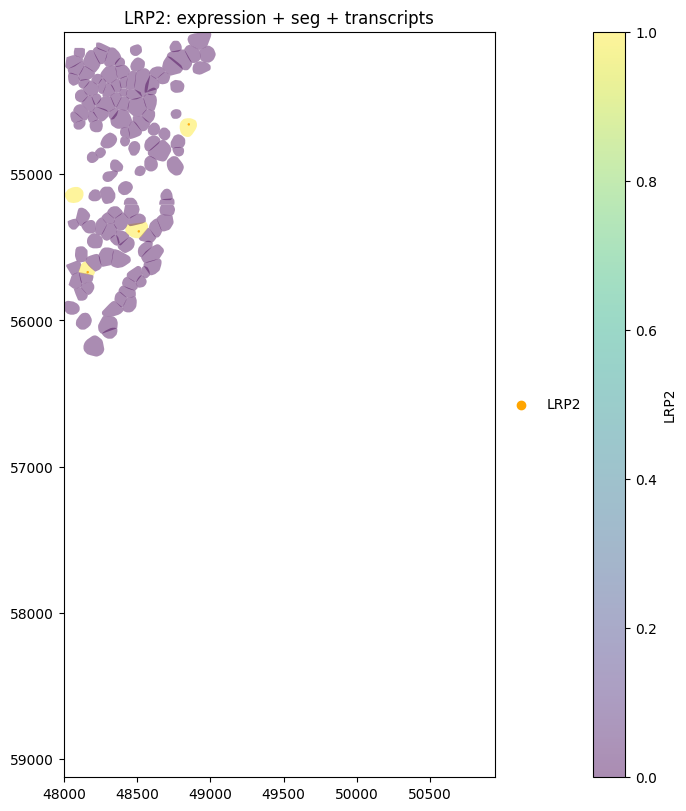

In [8]:
# Combined: gene expression + cell segmentation + transcripts (no morphology in GEO)
plot_gene_seg_transcripts(sdata_crop, GENE, point_size=0.5, point_alpha=0.6)